# SSY098
## Lab 0: Tutorial
### Introduction and objective
This lab is useful for students with only little experience working with visualization in python, but assumes an elementary familiarity with programming concepts in the language. 

The objective of this lab is to serve as an introduction to visualization of images and elementary image analysis. It may be used as a reference for common issues in the future labs. The difficulty increases as the tutorial progresses, and may be useful to gauge if there is anything you may need to rehearse.

Observe that you are expected to yourself look up documentation of given functions from libraries, e.g. OpenCV. It is highly encouraged to look at the documentation before asking for help.

You should fill in all skeleton functions and cells marked with `YOUR CODE HERE`. Sometimes, some parts in the functions are already given. 

In [5]:
# Import the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import correlate

There are many alternatives for working with images in Python. The most famous ones are Pillow and OpenCV, but it may also be done using Numpy and Matplotlib.

In [8]:
# Alternatives for loading images
from PIL import Image # Pillow library
import cv2 # OpenCV library

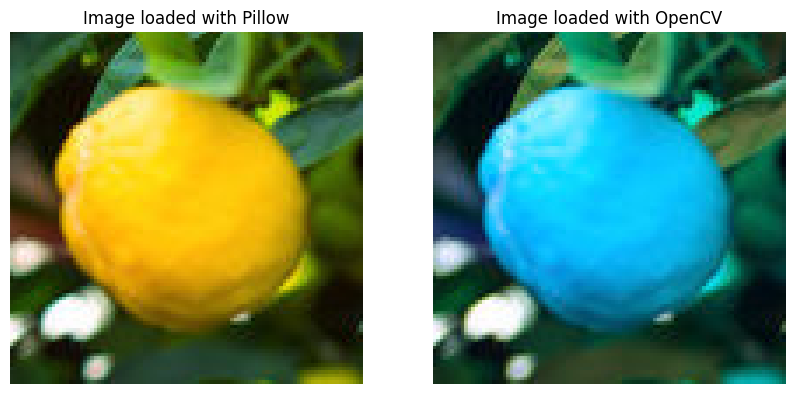

In [49]:
filepath = './data/lemon.png'

# Load the image using Pillow
image_pil = Image.open(filepath)

# Load the image using OpenCV
image_cv2 = cv2.imread(filepath)

# Display the images
f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title('Image loaded with Pillow')
ax[0].imshow(image_pil)
ax[0].axis('off')
ax[1].set_title('Image loaded with OpenCV')
ax[1].imshow(image_cv2)
ax[1].axis('off')
plt.show()

Woops, what is going on here?

An image is commonly a rectangular arrangement of pixels, with a height *H* and width *W* and number of channels *C*. 

Each pixel is associated with a colur. There are many different colour spaces. The most common representation is the RGB (*red-green-blue*) colour space (thus having *C=3*), where each channel contains the amount of pigment of these three base colours. Another common representation is the HSV/HSL (*hue-saturation-lightness*) space. 

Although the latter is very common in computer vision and image analysis tasks, we will assume that images are saved in RGB format throughout the course. 

Commonly, the spaces are slightly modified with an *alpha* channel, e.g. **RGB-A**, containing information about transparency in the image. These have *C=4* channels.

A grayspace image typically only has *C=1* channel.

 Let us check the structure of the corresponding arrays:

In [50]:
# Pillow creates a PIL.Image.Image object, while OpenCV creates a NumPy array. 
image_pil_array = np.array(image_pil)

print("Pillow image shape:", image_pil_array.shape)
print("OpenCV image shape:", image_cv2.shape)

Pillow image shape: (101, 101, 4)
OpenCV image shape: (101, 101, 3)


Pillow converts the image into a _(H, W, 4)_ image, and 4 denotes **RGB-A**, colour channels in the order of red-green-blue and alpha (transparency).

Matplotlib's `imshow` requires that images are of the following format: (*H*, *W*, *C*), where the number of channels is last, and may be between 1 and 4, but are always assumed to be in the order of RGB-(A).

Another common formats are _(C, H, W)_, which will not work with Matplotlib.

### Exercise 0.1 - Channels
Plot each corresponding channel of the Pillow image as subplots with shape (4, 1).

In [51]:
def plot_image_channels(image: np.ndarray, ax: plt.Axes):
    """Plot the color channels of the input image.
    
    Args:
        image (np.ndarray): Input image as a NumPy array.
        ax (plt.Axes): Matplotlib Axes object to plot the channels on.

    Returns:
        plt.Axes: The Matplotlib Axes object with the plotted channels.
    """
    
    assert ax.shape[0] == image.shape[-1], "Number of subplots must match number of channels"

    for c in range(image.shape[-1]):
        ax[c].imshow(image[:, :, c], cmap='gray')                                                                       
        ax[c].set_title(f'Channel {c}')          
        ax[c].axis('off')

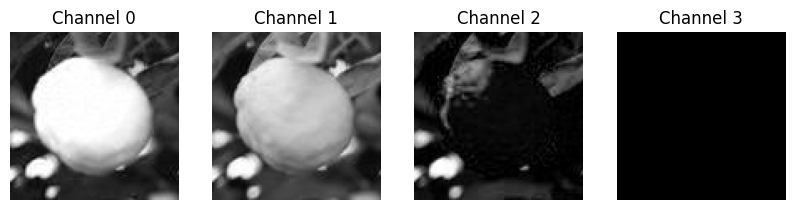

In [52]:
f, ax = plt.subplots(1, image_pil_array.shape[-1], figsize=(10, 5))
plot_image_channels(image_pil_array, ax)
plt.show()


Plot each corresponding channel of the OpenCV image as subplots of shape (3, 1).

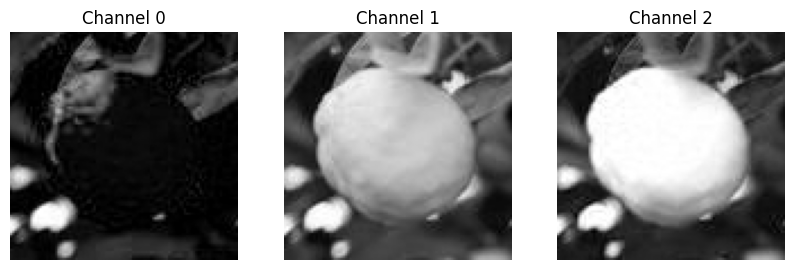

In [53]:
f, ax = plt.subplots(1, image_cv2.shape[-1], figsize=(10, 5))
plot_image_channels(image_cv2, ax)
plt.show()

We can now draw the conclusion that OpenCV uses **BGR** ordering of the colour channels. In order to use the standard order, write

In [42]:
image_cv2 = cv2.imread(filepath, cv2.IMREAD_COLOR_RGB)  # Load in RGB format instead of BGR

# Or alternatively
# image_cv2 = cv2.cvtColor(image_cv2, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB after loading

### Exercise 0.2 - Other colour spaces
We will now check a few other common colour spaces. OpenCV is a useful library to convert between different spaces. Write a helper function to get corresponding flags for converting to and from the following colour spaces:

- RGB
- HSV
- LAB
- YCR_CB

Write a function to fetch the correct flag for OpenCV and plot the channels for each representation.

In [58]:
def get_colour_space_flag(source_space: str, target_space: str) -> int:
    """Get the OpenCV color conversion flag for converting from source_space to target_space.
    
    Args:
        source_space (str): The source color space (e.g., 'RGB', 'BGR', 'HSV', 'LAB').
        target_space (str): The target color space (e.g., 'RGB', 'BGR', 'HSV', 'LAB').

    Returns:
        int: The OpenCV color conversion flag.
    """

    if (source_space == target_space):
        raise ValueError()

    conversion_table = {
        ("RGB", "BGR"): cv2.COLOR_RGB2BGR,
        ("RGB", "HSV"): cv2.COLOR_RGB2HSV,
        ("RGB", "LAB"): cv2.COLOR_RGB2LAB,
        
        ("BGR", "RGB"): cv2.COLOR_BGR2RGB,
        ("BGR", "HSV"): cv2.COLOR_BGR2HSV,
        ("BGR", "LAB"): cv2.COLOR_BGR2LAB,

        ("HSV", "RGB"): cv2.COLOR_HSV2RGB,
        ("HSV", "BGR"): cv2.COLOR_HSV2BGR,
        ("HSV", "LAB"): -1,

        ("LAB", "RGB"): cv2.COLOR_LAB2RGB,
        ("LAB", "BGR"): cv2.COLOR_LAB2BGR,
        ("LAB", "HSV"): -1,
    }

    return (conversion_table[(source_space, target_space)])

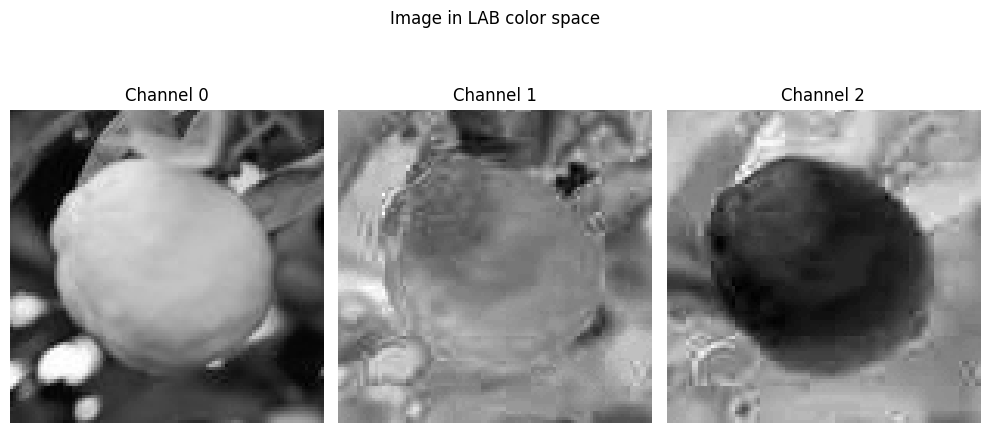

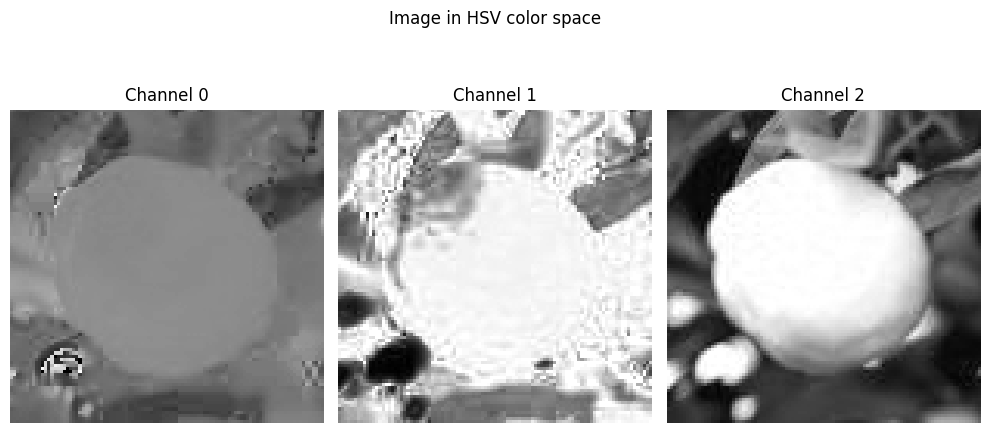

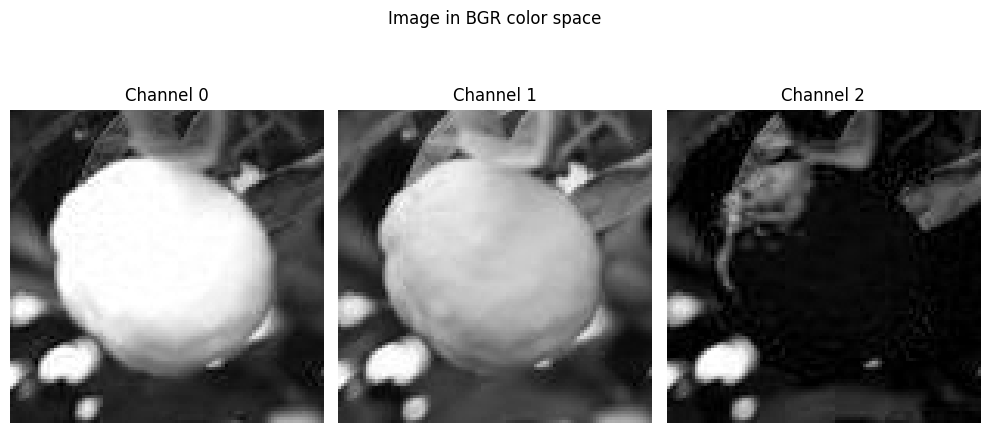

KeyError: ('RGB', 'YCR_CB')

In [59]:
for colour_space in ['LAB', 'HSV', 'BGR', 'YCR_CB']:
    flag = get_colour_space_flag('RGB', colour_space)
    image_converted = cv2.cvtColor(image_cv2, flag)

    f, ax = plt.subplots(1, image_converted.shape[-1], figsize=(10, 5))
    plot_image_channels(image_converted, ax)
    plt.suptitle(f'Image in {colour_space} color space')
    plt.tight_layout()
    plt.show()
    

Although they contain the same information, the different channels do not symbolize the same colour information as in the RGB case.

### Exercise 0.3 - Pixels and datatypes
An image is a set of pixels arranged in a rectangle, and each pixel has an *intensity*. 

The exact value of the intensity depends on the data format. In our case, we may see that the distribution of pixels is from 0-255.


In [ ]:
def plot_pixel_histogram(image: np.ndarray, ax: plt.Axes) -> plt.Axes:
    """
    Plot the histogram of pixel intensities for each color channel in the input image.

    Args:
        image (np.ndarray): Input image as a NumPy array.
        ax (plt.Axes): Matplotlib Axes object to plot the histogram on.

    Returns:
        plt.Axes: The Matplotlib Axes object with the histogram plotted.
    """
    
    # YOUR CODE HERE

    raise NotImplementedError

In [ ]:
# Plot the histogram of RBG pixel values
f, ax = plt.subplots(1, 1, figsize=(10, 5))
plot_pixel_histogram(image_cv2, ax)
plt.show()

In [ ]:
print("Datatype of RGB image:", image_cv2.dtype)

# Get the range of values of the image
min_value = np.min(image_cv2)
max_value = np.max(image_cv2)

print(f"Minimum value: {min_value}")
print(f"Maximum value: {max_value}")

Make a function to convert an image from `uint8` (0-255) to 0-1.

This indicates that the image at some point was quantized as an unsigned integer with 8 bits.

This datatype, `uint8`, is the most common, with each pixel taking values from 0 to 2<sup>8</sup>-1 (0-255). In medical images, it is not uncommon to see 16-bit unsigned integers, `uint16`, with values in the range 0 to 2<sup>16</sup> (0-65535). However, it is more convenient to work in floating point values ranging between 0 to 1.

In [ ]:
def uint8_to_float(image: np.ndarray) -> np.ndarray:
    """Convert an image from uint8 to float representation."""
    # YOUR CODE HERE

    raise NotImplementedError()

In [ ]:
# Convert image to 0-1 range
image = uint8_to_float(image_cv2)

# Get the range of values of the image
min_value = np.min(image)
max_value = np.max(image)

print(f"Minimum value: {min_value}")
print(f"Maximum value: {max_value}")


In deep learning, it is common to standardize images to a normal distribution with zero mean and unit variance.

In [ ]:
def standardize(image: np.ndarray) -> np.ndarray:
    """Standardize the image to have zero mean and unit variance."""
    
    # YOUR CODE HERE

    raise NotImplementedError()

In [ ]:
standardized_image = standardize(image)

print(f"Minimum value of standardized image: {np.min(standardized_image)}")
print(f"Maximum value of standardized image: {np.max(standardized_image)}")

f, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].set_title('Original Image')
ax[0].imshow(image_cv2)
ax[0].axis('off')
ax[1].set_title('Normalized Image')
ax[1].imshow(image)
ax[1].axis('off')
ax[2].set_title('Standardized Image')
ax[2].imshow(standardized_image)
ax[2].axis('off')
plt.show()

Matplotlib's `imshow` handles floating point values between 0-1 automatically, but cannot handle negative values.

### Exercise 0.4 - Indexing and cropping
Python uses 0-based indexing. For a pixel at row `r`, column `c`: `value = I[r,c]`. Linear indexing can be done with `ravel()` and `unravel_index()`, which flattens the indices to one long vector. However, it is important to note that this is done differently in different languages, depending on how arrays are stored in memory. In `numpy` in Python, arrays are stored row-major, meaning they are flattened row-by-row.

Replace the diagonal elements of the image with zero intensity pixels, using two for loops.



In [ ]:
def set_diagonal_to_zero(image: np.ndarray) -> np.ndarray:
    """Set the diagonal of the image to zero."""
    
    # YOUR CODE HERE

    raise NotImplementedError()

In [ ]:
image_to_modify = image_cv2.copy()

# Replace the diagonal of the image with zeros
image_to_modify = set_diagonal_to_zero(image_to_modify)

f, ax = plt.subplots(1, 1, figsize=(5,5))
ax.set_title('Image with Diagonal Set to Zero')
ax.imshow(image_to_modify)
ax.axis('off')
plt.show()

Flat indexing of images is often very useful. Sometimes looping over pixels in an image is unavoidable, and it may often be more efficient to be able to do linear indexing in these cases. As such, try to set the 275th to 350th pixels to only red in the sample image using `ravel`.

In [ ]:
def set_pixel_value_to_red(image: np.ndarray, pixels: int | list) -> np.ndarray:
    """Set the pixel values at `pixels` to the specified RGB value.
    
    Args:
        image: Input image as a NumPy array of shape (H, W, C).
        pixels: An integer or a list of integers specifying the pixel indices to modify. 
                The pixel index is calculated as `pixel_index = row * width + column`.
    Returns:
        Modified image with specified pixels set to red.
    """

    # YOUR CODE HERE

    raise NotImplementedError()

In [ ]:
# Display the image with the modified pixels
modified_image = set_pixel_value_to_red(image_to_modify, pixels=range(275, 350))

f, ax = plt.subplots(1, 1, figsize=(5,5))
ax.set_title('Image with Pixel Set to Red')
ax.imshow(modified_image)
ax.axis('off')
plt.show()

### Exercise 0.5 - Rotation
Rotation may be done manually, using a rotation matrix. Each pixel is a coordinate $(x,y)$ with a corresponding intensity $I$. Rotating a point $(x,y)$ with an angle $\theta$ is equivalent to moving it in the pixel grid such that
$$
\begin{pmatrix}
x' \\
y' \\
\end{pmatrix}
=
\begin{pmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{pmatrix}
\begin{pmatrix}
x \\
y \\
\end{pmatrix}
$$

However, in order for this to work, pixel coordinates must be centred around the origin. We thus

1. Create a grid of pixel coordinates $(x',y')$
2. Centre the coordinates $(x',y')$.
3. Apply the rotation matrix.
4. Shift the coordinates $(x',y')$ back.
5. Fill an image at positions $(x',y')$ using values from $(x,y)$.

You will implement the rotation matrix, shifting of coordinates and the application of the rotation matrix transform, as defined above.


In [ ]:
def get_rotation_matrix(theta_in_degrees: float) -> np.ndarray:
    """Get the 2D rotation matrix for a given angle in degrees.
    
    Args:
        theta_in_degrees: The rotation angle in degrees.
    
    Returns:
        A 2x2 rotation matrix.
    """

    # YOUR CODE HERE

    raise NotImplementedError()
    

def shift_coordinates(coords: np.ndarray, distance: float) -> np.ndarray:
    """Shift the given coordinates by a specified distance in the positive x-direction.
    
    Args:
        coords: A 1D array of shape (1, n) representing n points in 2D space.
        distance: The distance to shift the coordinates.
    Returns:
        A 1D array of shape (1, n) representing the shifted points.
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()

def apply_rotation(coords: np.ndarray, rotation_matrix: np.ndarray) -> np.ndarray:
    """Apply the given rotation matrix to a set of coordinates.
    
    Args:
        coords: A 2D array of shape (2, n) representing n points in 2D space.
        rotation_matrix: A 2x2 rotation matrix.
    
    Returns:
        A 2D array of shape (2, n) representing the rotated points.
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()


In [ ]:
# Use a flipping matrix to flip the image horizontally
theta = 180  # Rotation angle in degrees
rotation_matrix = get_rotation_matrix(theta)

# 1) Make a grid of pixel coordinates, shift the origin to the center of the image, and apply the rotation
height, width, _ = modified_image.shape
x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))


# 2) Shift the coordinates to the center
x_coords_centered = shift_coordinates(x_coords, width / 2)
y_coords_centered = shift_coordinates(y_coords, height / 2)

# 3) Apply the rotation
coords = np.vstack((x_coords_centered.flatten(), y_coords_centered.flatten()))
new_coords = apply_rotation(coords, rotation_matrix)
new_x_coords = new_coords[0, :].reshape(height, width)
new_y_coords = new_coords[1, :].reshape(height, width)

# 4) Shift the coordinates back to the original origin
new_x_coords = shift_coordinates(new_x_coords, -width / 2)
new_y_coords = shift_coordinates(new_y_coords, -height / 2)

# Round the coordinates to the nearest integer
new_x_coords = np.round(new_x_coords).astype(int)
new_y_coords = np.round(new_y_coords).astype(int)

# 5) Create an empty image and fill it with the rotated pixel values
# Need to loop through the new coordinates and assign the pixel values from the modified image to the new locations in the rotated image
rotated_image = np.zeros_like(modified_image)
for i in range(height):
    for j in range(width):
        new_x = new_x_coords[i, j]
        new_y = new_y_coords[i, j]
        if 0 <= new_x < width and 0 <= new_y < height:
            rotated_image[new_y, new_x] = modified_image[i, j]

f, ax = plt.subplots(1, 1, figsize=(5,5))
ax.set_title('Rotated Image')
ax.imshow(rotated_image)
ax.axis('off')
plt.show()



This is pretty arduous work. When rotating at general angles, the exact coordinates of transformed pixels may have to be estimated in a process called warping, and pixels out of view must be filled with some constant. We show how to do this with `cv2` below.

In [ ]:
# Using cv2.warpAffine for rotation
rotation_matrix_cv2 = cv2.getRotationMatrix2D((width / 2, height / 2), theta, 1)
rotated_image_cv2 = cv2.warpAffine(modified_image, rotation_matrix_cv2, (width, height))

f, ax = plt.subplots(1, 1, figsize=(5,5))
ax.set_title('Rotated Image using cv2.warpAffine')
ax.imshow(rotated_image_cv2)
ax.axis('off')
plt.show()

### Exercise 0.6 - Linear Filters

In this exercise, you will implement both average and Gaussian filters manually, then compare your results to the built-in functions in OpenCV. The typical objective of these images is to reduce noise in the image, and de-emphasize borders and abrupt changes.

A mean/average filter $w_k$ of size $k$ defines a kernel consisting of only ones, normalized to preserve the intensity:

$$
w_3 = \frac{1}{9}\begin{pmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1 \\
\end{pmatrix}
$$

A Gaussian filter $w_{\sigma}$ with standard deviation $\sigma$ is defined as a Gaussian distribution over a small grid $(x,y)$:
$$
\tilde w_{\sigma}(x,y) = \frac{1}{2\pi\sigma^2}\exp{\left(-(x^2+y^2)/(2\sigma^2)\right)} 
$$
$$
w_{\sigma}(x,y) = \frac{\tilde w_{\sigma}(x,y)}{\sum_{x,y} \tilde w_{\sigma}(x,y)}
$$


1. Implement an average filter (box filter) manually using convolution.
2. Implement a Gaussian filter manually using a Gaussian kernel and convolution.
3. Apply both filters to an example image and visualize the results.
4. Compare your results to `cv2.blur` (average filter) and `cv2.GaussianBlur` (Gaussian filter).

Discuss any differences you observe between your manual implementation and the OpenCV functions.

In [ ]:
def image_to_grayscale(image: np.ndarray) -> np.ndarray:
    """
     Convert a color image to grayscale.
    
    Args:
        image (np.ndarray): Input color image as a NumPy array of shape (H, W, C).
    Returns:
        np.ndarray: Grayscale image as a NumPy array of shape (H, W)

    """
    
    # YOUR CODE HERE

    raise NotImplementedError()

def gaussian_kernel(size: int, sigma: float) -> np.ndarray:
    """Generates a Gaussian kernel.
    
    Args:
        size (int): The size of the kernel (must be odd).
        sigma (float): The standard deviation of the Gaussian distribution.
    
    Returns:
        np.ndarray: A 2D array representing the Gaussian kernel.
    """

    # YOUR CODE HERE

    raise NotImplementedError()

def mean_kernel(size: int) -> np.ndarray:
    """Generates a mean (box) kernel.
    
    Args:
        size (int): The size of the kernel (must be odd).
    
    Returns:
        np.ndarray: A 2D array representing the mean kernel.
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()

def apply_kernel(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Apply `kernel` to `image` using cross-correlation (compare the lecture slides).
    
    Args:
        image: A 2D array representing the input image.
        kernel: A 2D array representing the cross-correlation kernel.
    
    Returns:
        np.ndarray: A 2D array representing the cross-correlated image.
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()

In [ ]:
# Create a gray-scale image
image_gray = image_to_grayscale(modified_image)

# Apply mean filter
mean_kernel_size = 5
mean_filter = mean_kernel(mean_kernel_size)
blurred_mean = apply_kernel(image_gray, mean_filter)

# Apply Gaussian filter 
gaussian_kernel_size = 5
gaussian_sigma = 1
gaussian_filter = gaussian_kernel(gaussian_kernel_size, gaussian_sigma)
blurred_gaussian = apply_kernel(image_gray, gaussian_filter)

# Compare with cv2
blurred_mean_cv2 = cv2.blur(image_gray, (mean_kernel_size, mean_kernel_size))
blurred_gaussian_cv2 = cv2.GaussianBlur(image_gray, (gaussian_kernel_size, gaussian_kernel_size), gaussian_sigma)


f, ax = plt.subplots(2, 3, figsize=(15, 5))
ax[0,0].set_title('Original Grayscale Image')
ax[0,0].imshow(image_gray, cmap='gray')
ax[0,0].axis('off')
ax[0,1].set_title('Mean Blurred Image')
ax[0,1].imshow(blurred_mean, cmap='gray')
ax[0,1].axis('off')
ax[0,2].set_title('Gaussian Blurred Image')
ax[0,2].imshow(blurred_gaussian, cmap='gray') 
ax[0,2].axis('off')
ax[1,0].set_title('Original Grayscale Image (cv2)')
ax[1,0].imshow(image_gray, cmap='gray')
ax[1,0].axis('off')
ax[1,1].set_title('Mean Blurred Image (cv2)')
ax[1,1].imshow(blurred_mean_cv2, cmap='gray')
ax[1,1].axis('off')
ax[1,2].set_title('Gaussian Blurred Image (cv2)')
ax[1,2].imshow(blurred_gaussian_cv2, cmap='gray')
ax[1,2].axis('off')
plt.tight_layout()
plt.show()


### Exercise 0.7 - Simple Gradient Filter

In this exercise, we will consider filters that instead highlights changes, such as edges, in images. The easiest is simply to compute the difference between an image and a shifted version of the same image.

- Pad an image with `size` pixels.
- Shift a copy of the original image by `size` pixels.
- Compute the difference between the padded and shifted image.
- Compute the magnitude of the difference.

This creates a simple difference filter in the direction of shift.

In [ ]:
def shift_image(image: np.ndarray, shift_x: int, shift_y: int) -> np.ndarray:
    """Shift the image by `shift_x` pixels horizontally and `shift_y` pixels vertically.
    
    Args:
        image: A 2D array representing the input image.
        shift_x: The number of pixels to shift horizontally (positive for right, negative for left).
        shift_y: The number of pixels to shift vertically (positive for down, negative for up).

    Returns:
        np.ndarray: A 2D array representing the shifted image.
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()

In [ ]:
# Pad the image with zeros on the border to handle edge cases in convolution
size = 1
padded_image = np.pad(image_gray, pad_width=size, mode='constant', constant_values=0)

# Image must be converted to float. Why?
padded_image = padded_image.astype(np.float32)

# Shift image by size pixels to the right
shifted_image = np.zeros_like(padded_image)
shifted_image[:, size:] = padded_image[:, :-size]

# Compute the difference between the original and shifted image
difference_image = padded_image - shifted_image
magnitude_of_difference = np.abs(difference_image)

f, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].set_title('Original Grayscale Image')
ax[0].imshow(image_gray, cmap='gray')
ax[0].axis('off')
ax[1].set_title('Difference Image')
ax[1].imshow(difference_image, cmap='gray')
ax[1].axis('off')
ax[2].set_title('Magnitude of Difference')
ax[2].imshow(magnitude_of_difference, cmap='gray')
ax[2].axis('off')
plt.tight_layout()
plt.show()

Observe that the red line is invisible when computing the difference in the horizontal direction.

Next, you will implement a simple gradient filter and compare it to the Sobel operator.

- Convert the input image to grayscale.
- Implement horizontal and vertical gradient kernels (central difference) and apply them via convolution.
- Compute and display the gradient magnitude.
- Compare your result with `cv2.Sobel` (or `scipy.ndimage.sobel`).

The filter kernel $G_x$ of a simple gradient filter in the $x$ direction simply computes the difference of the adjacent pixels, e.g. in the simplest case
$$
G_x = \begin{pmatrix}
-1 \\
0 \\
1 \\
\end{pmatrix}
$$

Hint: use small kernels like `[-1, 0, 1]` (horizontal) and its transpose (vertical). Experiment with kernel variants and comment on differences.

We compare with the Sobel operator, which has gradient kernels
$$
G_x = \begin{pmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1 \\
\end{pmatrix}, \quad G_y = \begin{pmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1 \\
\end{pmatrix}.
$$


In [ ]:
def central_diff_kernel_x():
    """Return a 1x3 horizontal central-difference kernel.
    Scipy's `convolve` expects the kernel to have the same number of dimensions
    as the input image (2 for a 2D image). 

    Args:
        None
    Returns:
        np.ndarray: A 2D array representing the horizontal central-difference kernel.
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()


def central_diff_kernel_y():
    """Return the vertical kernel (transpose of central_diff_kernel_x).
    
    Args:
        None
    Returns:
        np.ndarray: A 2D array representing the vertical central-difference kernel.
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()

In [ ]:
gx = central_diff_kernel_x()
gy = central_diff_kernel_y()

# Compute manual gradients
image_gray = image_gray.astype(np.float32)  

# Why do we have to convert to float?

grad_x = apply_kernel(image_gray, gx)
grad_y = apply_kernel(image_gray, gy)
grad_mag = np.hypot(grad_x, grad_y)

# Compare with OpenCV Sobel
sobel_x = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.hypot(sobel_x, sobel_y)

# Visualization
f, ax = plt.subplots(2, 4, figsize=(15, 10))
ax[0, 0].set_title('Grayscale')
ax[0, 0].imshow(image_gray, cmap='gray')
ax[0, 0].axis('off')

ax[0, 1].set_title('Manual grad_x')
ax[0, 1].imshow(grad_x, cmap='gray')
ax[0, 1].axis('off')

ax[0, 2].set_title('Manual grad_y')
ax[0, 2].imshow(grad_y, cmap='gray')
ax[0, 2].axis('off')

ax[0, 3].set_title('Manual grad_mag')
ax[0, 3].imshow(grad_mag, cmap='gray')
ax[0, 3].axis('off')

ax[1, 0].set_title('Grayscale')
ax[1, 0].imshow(image_gray, cmap='gray')
ax[1, 0].axis('off')

ax[1, 1].set_title('Sobel grad_x')
ax[1, 1].imshow(sobel_x, cmap='gray')
ax[1, 1].axis('off')

ax[1, 2].set_title('Sobel grad_y')
ax[1, 2].imshow(sobel_y, cmap='gray')
ax[1, 2].axis('off')

ax[1, 3].set_title('Sobel grad_mag')
ax[1, 3].imshow(sobel_mag, cmap='gray')
ax[1, 3].axis('off')

plt.tight_layout()
plt.show()

Your own filters should be very close to the Sobel results. The result also is very similar to the first difference computation, emphasizing the changes (gradient/difference) between objects in the image.

### Exercise 0.8 — Morphological Operations and Segmentation

In this exercise, you should use OpenCV's built-in morphological operations on a binarized version of the image. The objective is to display the power of simple binary operations for image processing.

For morphological operations, the foreground is defined as all pixels with value 1, while background has 0 value.

The basis of morphological operations is the _structuring element_, which defines the neighbourhood of a pixel, in essence, what counts as neighbours of a given pixel. For example, it may look like
$$
s = \begin{pmatrix}
0 & 1 & 0 \\
0 & 1 & 0 \\
0 & 1 & 0 \\
\end{pmatrix}
$$
which means only immediate vertical neighbours are considered. A common one is
$$
s = \begin{pmatrix}
0 & 1 & 0 \\
1 & 1 & 1 \\
0 & 1 & 0 \\
\end{pmatrix}
$$
which simply ignores diagonal neighbours.

There are four main types of operations, that may be composed to create more advanced ones.
#### Erosion
Shrinks, or erodes, the edges of a foreground objects. Using convolution, a pixel in the eroded image will kept as 1 only if all neighbours according to the structural element are 1. Otherwise, the resulting pixel will be set as 0. The result is a thinner object in the image.

#### Dilation

Dilation expands objects by setting each output pixel to 1 if at least one pixel in the neighborhood defined by the structuring element is 1.

#### Opening

Opening is erosion followed by dilation. The effect is that small objects outside the foreground are entirely removed, while larger objects are first thinned, and then thickened back to their original size.

#### Closing
Closing is dilation followed by erosion. It is used to close small holes in the foreground.

In [ ]:
# Apply some salt-and-pepper noise to the binary image
noise_density = 0.05

# Threshold the image to create a binary image
threshold_value = 100
_, binary_image = cv2.threshold(image_gray, threshold_value, 255, cv2.THRESH_BINARY)
binary_image = binary_image.astype(np.uint8)

# Get random indices for salt-and-pepper noise
num_salt = int(noise_density * binary_image.size * 0.5)
num_pepper = int(noise_density * binary_image.size * 0.5)

# Add salt noise (white pixels)
salt_indices = np.random.choice(binary_image.size, num_salt, replace=False)
binary_image.flat[salt_indices] = 255

# Add pepper noise (black pixels)
pepper_indices = np.random.choice(binary_image.size, num_pepper, replace=False)
binary_image.flat[pepper_indices] = 0


f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title('Grayscale Image')
ax[0].imshow(image_gray, cmap='gray')
ax[0].axis('off')
ax[1].set_title(f'Noisy binary Image at Threshold {threshold_value}')
ax[1].imshow(binary_image, cmap='gray')
ax[1].axis('off')
plt.tight_layout()
plt.show()

Your objective is to remove the salt-and-pepper noise from the binarized image using morphological operations. Combine erosion and dilation using a custom structuring element using the OpenCV function `cv2.morphologyEx` and operation flags such as `cv2.MORPH_ERODE`.

In [ ]:
def structuring_element() -> np.ndarray:
    """Define a custom structuring element for morphological operations. For example, a 3x3 cross-shaped structuring element can be defined as follows:

    [[0, 1, 0],
     [1, 1, 1],
     [0, 1, 0]]

    Returns:
        np.ndarray: A 2D array representing the structuring element.
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()

def remove_salt_and_pepper_noise(image: np.ndarray, structuring_element: np.ndarray) -> np.ndarray:
    """Remove salt-and-pepper noise from a binary image using morphological operations.

    Args:
        image (np.ndarray): Input binary image with salt-and-pepper noise as a NumPy array of shape (H, W).
        structuring_element (np.ndarray): A 2D array representing the structuring element for morphological operations.

    Returns:
        np.ndarray: Denoised binary image as a NumPy array of shape (H, W).
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()


In [ ]:
# Define the structuring element
se = structuring_element()

# Remove salt-and-pepper noise from the binary image
denoised_image = remove_salt_and_pepper_noise(binary_image, se)

f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title('Noisy Binary Image')
ax[0].imshow(binary_image, cmap='gray')
ax[0].axis('off')
ax[1].set_title('Denoised Binary Image')
ax[1].imshow(denoised_image, cmap='gray')
ax[1].axis('off')
plt.tight_layout()
plt.show()

### Exercise 0.9 - Segmentation
In this final task, you should segment the lemon in the given image. To do this, you will be given a full recipe to implement.

Observe in the initial exercises, that the lemon is well represented by the last channel in the YCR_CB colour space. We will start there to create a _segmentation mask_ of the lemon.

1. Convert the image to YCR_CB.
2. Use the _inverted_ last channel as grayscale.
3. Apply a Gaussian filter.
4. Binarize at a given threshold.
5. Apply morphological operations.
6. Generate the segmentation mask.

In [ ]:
def convert_to_ycrcb(image: np.ndarray) -> np.ndarray:
    """Convert an RGB image to YCrCb color space using OpenCV.

    Args:
        image (np.ndarray): Input RGB image as a NumPy array of shape (H, W, 3).
    Returns:
        np.ndarray: Image in YCrCb color space as a NumPy array of shape (H, W, 3).
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()


def apply_gaussian_filter(image: np.ndarray, kernel_size: int, sigma: float) -> np.ndarray:
    """Apply a Gaussian filter to the input image.

    Args:
        image (np.ndarray): Input image as a NumPy array of shape (H, W).
        kernel_size (int): Size of the Gaussian kernel (must be odd).
        sigma (float): Standard deviation of the Gaussian distribution.
    
    Returns:
        np.ndarray: Blurred image as a NumPy array of shape (H, W).
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()

def binarize_image(image: np.ndarray, threshold: int) -> np.ndarray:
    """Binarize the input image using a specified threshold.

    Args:
        image (np.ndarray): Input grayscale image as a NumPy array of shape (H, W).
        threshold (int): Threshold value for binarization.
    
    Returns:
        np.ndarray: Binarized image as a NumPy array of shape (H, W).
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()


def segment(image, kernel_size: int, sigma: float, threshold: int, structuring_element_size: int) -> np.ndarray:
    """Segment the input image by applying Gaussian blur followed by binarization.

    Args:
        image (np.ndarray): Input YCrCb image as a NumPy array of shape (H, W, 3).
        kernel_size (int): Size of the Gaussian kernel (must be odd).
        sigma (float): Standard deviation of the Gaussian distribution.
        threshold (int): Threshold value for binarization.
        structuring_element_size (int): Size of the structuring element for morphological operations.

    Returns:
        np.ndarray: Segmented binary image as a NumPy array of shape (H, W).
    """
    
    # YOUR CODE HERE

    raise NotImplementedError()

In [ ]:
image_ycrcb = convert_to_ycrcb(image_cv2)

f, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].set_title('Image in YCbCR Color Space')
ax[0].imshow(image_ycrcb)
ax[0].axis('off')
ax[1].set_title('Grayscale Image (Y channel)')
ax[1].imshow(image_ycrcb[:, :, 0], cmap='gray')
ax[1].axis('off')
ax[2].set_title('Grayscale Image (Cb channel)')
ax[2].imshow(image_ycrcb[:, :, 1], cmap='gray')
ax[2].axis('off')
ax[3].set_title('Grayscale Image (Cr channel)')
ax[3].imshow(image_ycrcb[:, :, 2], cmap='gray')
ax[3].axis('off')
plt.tight_layout()
plt.show()

Use histogram of pixels to find a good threshold of high-value pixels, in order to remove as much background as possible.

In [ ]:
# Plot the histogram of the channel to find a good threshold
f, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.set_title('Pixel Intensity Histogram of Y channel')
ax.hist(image_ycrcb[:, :, 1].flatten(), bins=256, color='gray', alpha=0.5)
ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Frequency')
plt.show()

# YOUR CODE HERE
threshold = ...

In [ ]:
image_gray = image_ycrcb[:, :, 1]
segmentation_mask = segment(image_gray, kernel_size=5, sigma=1, threshold=threshold, structuring_element_size=5)

# Set the background pixels in the mask to nane for better visualization
segmentation_mask = np.where(segmentation_mask == 0, np.nan, segmentation_mask)

f, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.set_title('Segmented Image')
ax.imshow(image_cv2)
ax.imshow(segmentation_mask, cmap='Reds', alpha=0.5)  # Overlay the segmentation mask on the original image
ax.axis('off')
plt.show()